# Notebook Objective -  Retention within a nursery


In [2]:
import xarray as xr
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import os
import geopandas as gpd

from shapely.geometry import LineString
from shapely.geometry import Point, Polygon as ShapelyPolygon
import matplotlib.pyplot as plt
import seaborn as sns

import cmocean
import cmocean.cm as cmo

import matplotlib.patheffects as path_effects
from matplotlib.lines import Line2D
from matplotlib.patches import Polygon
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors


In [3]:
import importlib
import utils  # Importing the utils module

In [4]:
extents = utils.extents


In [5]:
# File Paths to data
repo_path = '/Users/zephyrsylvester/repos/circumpolar-connectivity-analysis/'
data_path = repo_path + 'data/'
fig_path = repo_path + 'figures/'

ibsco_path = data_path + 'IBSCO/'

tab_path = fig_path + 'tables/'
map_path = fig_path + 'maps/'

In [6]:
# Import Utils for consistent naming, colors, labling, and mapping
importlib.reload(utils) # Run this if you update something in your utils file you need

# Import necessary data and functions from utils
hypotheses = utils.hypotheses
stages = utils.stages
locations = utils.locations
start_years = utils.start_years
months_data = utils.months_data
extents = utils.extents
bathymetry = utils.bathymetry

# function
plot_region = utils.plot_region
plot_contour = utils.plot_contour

In [7]:
importlib.reload(utils) # Run this if you update something in your utils file you need

boxes = {key: value['boxes'] for key, value in locations.items()}
location_labels = {key: value['name'] for key, value in locations.items()}
location_order = {key: value['order'] for key, value in locations.items()}

# Different Hypotheses (in this case only hi res)
hypotheses = utils.hypotheses
hypotheses_name = {key: value['name'] for key, value in hypotheses.items()}
hypothesis_labels = {key: value['label'] for key, value in hypotheses.items()}
hypothesis_order = {key: value['order'] for key, value in hypotheses.items()}

start_years = utils.start_years
sy_labels = {key: value['label'] for key, value in start_years.items()}
sy_marker = {key: value['marker'] for key, value in start_years.items()}

extent = extents['hires']

In [8]:
print(location_labels)
print(extents)

{'BS': 'BS', 'GERL': 'GS', 'GP': 'GP', 'MB2': 'MB'}
{'BS-NG': [278, 316, -64, -60], 'base': [275, 311, -72, -59], 'expand': [274, 316, -71, -60], 'toSG': [281.6, 322, -65, -60], 'toAM': [271, 308, -71, -62], 'hires': [269, 309, -72, -59], 'bells': [265.54, 305.32, -75.4, -62.8], 'WAPtoamund': [226.93, 312.34, -76.995, -62.365]}


In [9]:
# Plotting Data
# Path to the downloaded NetCDF file
nc_path = ibsco_path + 'IBCSO_v2_bed_WGS84_500m_APregion.nc'
# nc_path = ibsco_path + 'IBCSO_v2_bed_WGS84_500m_SWSect.nc'

# Open the NetCDF file using xarray
ds = xr.open_dataset(nc_path)


In [10]:
# Helper function to plot the base map and all boxes
def plot_nurseries_bw(ax, extent, locations, box_zorder=6):
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    # Plot all bounding boxes
    for region, loc_data in locations.items():
        for box in loc_data['boxes']:
            lonpoly = box['lonpoly']
            latpoly = box['latpoly']
            poly = Polygon(list(zip(lonpoly, latpoly)), closed=True, fill=False, edgecolor='k', zorder=box_zorder, transform=ccrs.PlateCarree())
            ax.add_patch(poly)

# Helper function to plot the base map and all boxes
def plot_nurseries_bw_fill(ax, extent, locations, box_zorder=6):
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    # Plot all bounding boxes
    for region, loc_data in locations.items():
        for box in loc_data['boxes']:
            lonpoly = box['lonpoly']
            latpoly = box['latpoly']
            poly = Polygon(list(zip(lonpoly, latpoly)), closed=True, fill=True, color ='k', alpha=0.1, zorder=box_zorder, transform=ccrs.PlateCarree())
            ax.add_patch(poly)


# Helper function to plot the base map and specific nursery box
def plot_nurseries_individ(ax, extent, locations, nursery=None, box_zorder=6):
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    
    # If a specific nursery is provided, plot only that nursery
    if nursery in locations:
        loc_data = locations[nursery]
        for box in loc_data['boxes']:
            lonpoly = box['lonpoly']
            latpoly = box['latpoly']
            poly = Polygon(list(zip(lonpoly, latpoly)), closed=True, fill=False, edgecolor='k', zorder=box_zorder, transform=ccrs.PlateCarree())
            ax.add_patch(poly)
    else:
        print(f"Nursery '{nursery}' not found in locations.")

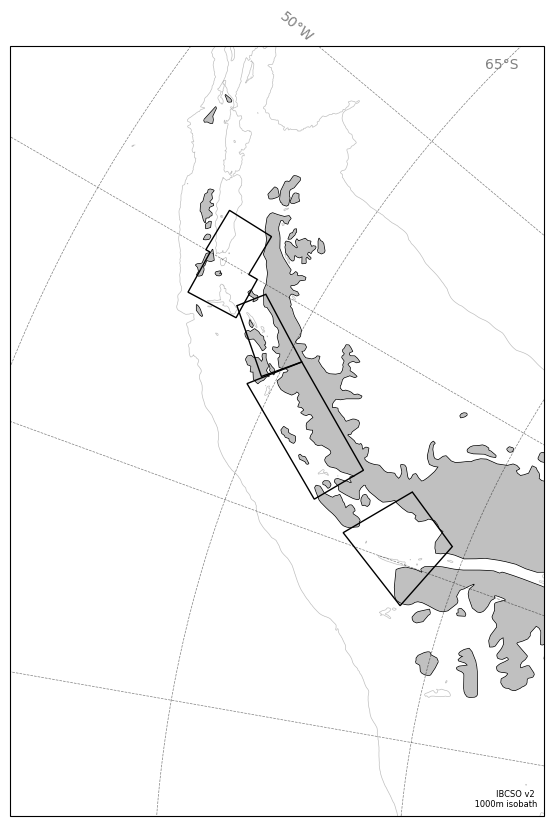

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10), subplot_kw={'projection': ccrs.SouthPolarStereo()})
extent = [275, 310, -68, -62]

plot_region(ax, extent)  # Sets up the map with coastline, land, gridlines, etc.
plot_contour(ax, extent)
plot_nurseries_bw(ax, extent, locations)
plt.show()

In [12]:
def plot_reference_map_with_labels(ax, extent, locations, location_labels, location_order, sea_names, place_names, box_zorder=6, label_fontsize=12, place_fontsize=10):
    """
    Plot nurseries with bounding boxes, labels, and additional sea and place names.

    Parameters:
        ax (matplotlib.axes): The matplotlib axis to plot on.
        extent (list): The extent of the map in [lon_min, lon_max, lat_min, lat_max].
        locations (dict): Dictionary of locations with bounding boxes.
        location_labels (dict): Human-readable labels for locations.
        location_order (dict): Order for locations.
        sea_names (list): List of sea names with coordinates and labels.
        place_names (list): List of place names with coordinates, labels, and angles.
        box_zorder (int): Z-order for the boxes.
        label_fontsize (int): Font size for nursery and sea labels.
        place_fontsize (int): Font size for place names.
    """
    ax.set_extent(extent, crs=ccrs.PlateCarree())

    # Plot nurseries with labels
    for region in sorted(locations.keys(), key=lambda x: location_order[x]):
        for box in locations[region]['boxes']:
            lonpoly = box['lonpoly']
            latpoly = box['latpoly']
            
            # Plot bounding box
            poly = Polygon(list(zip(lonpoly, latpoly)), closed=True, fill=False, edgecolor='k', zorder=box_zorder, transform=ccrs.PlateCarree())
            ax.add_patch(poly)
            
            # Calculate centroid for label
            lon_center = np.mean(lonpoly)
            lat_center = np.mean(latpoly)
            
            # Add the label at the centroid with white outline
            text = ax.text(
                lon_center, lat_center, f"{location_labels.get(region, region)}\nNG", 
                fontsize=label_fontsize, color='black', ha='center', va='center', fontweight='bold',
                transform=ccrs.PlateCarree(), zorder=box_zorder + 1
            )
            # Add white outline to text
            text.set_path_effects([
                path_effects.Stroke(linewidth=2, foreground='white'),
                path_effects.Normal()
            ])

    # Plot sea names
    for sea in sea_names:
        ax.text(
            sea['lon'], sea['lat'], sea['name'], 
            fontsize=label_fontsize, color='black', ha=sea.get('ha', 'center'), va=sea.get('va', 'center'),
            transform=ccrs.PlateCarree(), zorder=box_zorder + 1,
            path_effects=[
                path_effects.Stroke(linewidth=2, foreground='white'),
                path_effects.Normal()
            ]
        )

    # Plot place names with lines and angles
    for place in place_names:
        angle = place.get('angle', 0)
        offset = place.get('offset_length') #0.7  # Adjust distance from the point to the label

        # Calculate label position based on angle
        label_lon = place['lon'] + offset * np.cos(np.radians(angle))
        label_lat = place['lat'] + offset * np.sin(np.radians(angle))

        # Draw a line connecting the place point to the label
        ax.plot([place['lon'], label_lon], [place['lat'], label_lat], 
                color='black', linewidth=0.5, transform=ccrs.PlateCarree(), zorder=box_zorder)

        # Add the place name label
        ax.text(
            label_lon, label_lat, place['name'], 
            fontsize=place_fontsize, color='black', ha=place.get('ha', 'center'), va=place.get('va', 'center'),
            fontstyle='italic',
            transform=ccrs.PlateCarree(), zorder=box_zorder + 1,
            path_effects=[
                path_effects.Stroke(linewidth=2, foreground='white'),
                path_effects.Normal()
            ]
        )

In [13]:
# place_names = [
#     {"name": "Elephant Is.", "lon": 304.7, "lat": -61.15,  "ha": "center", "va": "bottom", "angle": 90, "line_angle": 90},
#     {"name": "Joinville Is.", "lon": 304.6, "lat": -63.25, "ha": "center", "va": "bottom", "angle": 90, "line_angle": 270},
#     {"name": "Boyd St.", "lon": 298.3, "lat": -63.2, "ha": "center", "va": "top", "angle": 135, "line_angle": 135},
#     {"name": "Anvers Is.", "lon": 296.3, "lat": -64.6,  "ha": "center", "va": "top", "angle": 150, "line_angle": 270},
#     {"name": "Adelaide Is.", "lon": 291.65, "lat": -67.2,  "ha": "center", "va": "top", "angle": 160, "line_angle": 180},
#     {"name": "Alexander Is.", "lon": 288.5, "lat": -69.1, "ha": "center", "va": "top", "angle": 180, "line_angle": 180}
# ]

In [14]:
place_names = [
    {"name": "Elephant Is.", "lon": 304.7, "lat": -61.15,  "ha": "right", "va": "bottom", "angle": 90, "offset_length": 0.5},
    {"name": "Joinville Is.", "lon": 304.6, "lat": -63.25, "ha": "left", "va": "bottom", "angle": 10, "offset_length": 1},
    {"name": "Boyd St.", "lon": 298.3, "lat": -63.2, "ha": "right", "va": "top", "angle": 150, "offset_length": 1},
    {"name": "Anvers Is.", "lon": 296.3, "lat": -64.6,  "ha": "right", "va": "top", "angle": 150, "offset_length": 1},
    {"name": "Adelaide Is.", "lon": 291.65, "lat": -67.2,  "ha": "right", "va": "top", "angle": 160, "offset_length": 1},
    {"name": "Alexander Is.", "lon": 288.5, "lat": -69.1, "ha": "right", "va": "top", "angle": 180, "offset_length": 2}
]

	# •	"ha": "right" and "va": "center" for labels to the right of a point.
	# •	"ha": "center" and "va": "top" for labels directly above a point.

sea_names = [
    {"name": "WEDDELL SEA", "lon": 305, "lat": -67, "ha": "center", "va": "center"},
    {"name": "BELLINGSHAUSEN SEA", "lon": 279, "lat": -69, "ha": "center", "va": "center"}
]

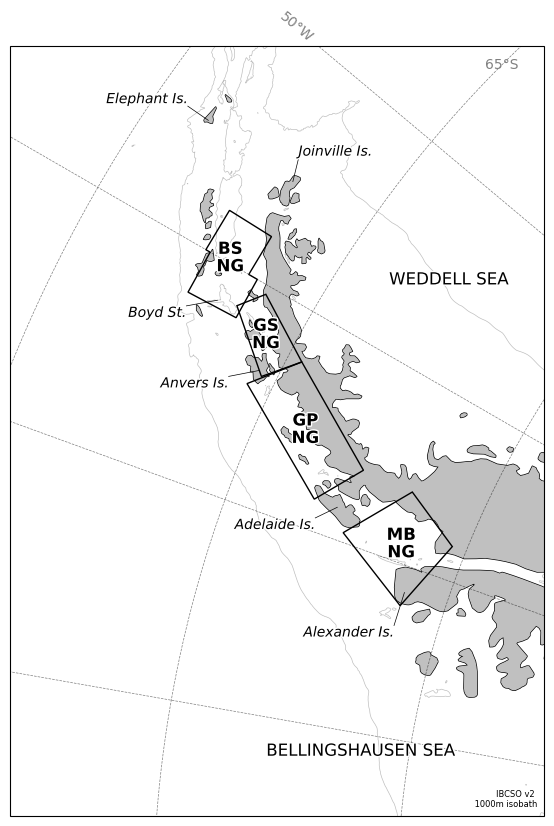

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10), subplot_kw={'projection': ccrs.SouthPolarStereo()})
extent = [275, 310, -68, -62]

# Set up the map
plot_region(ax, extent)  # Adds coastline, land, and gridlines
plot_contour(ax, extent)  # Adds bathymetry contours

# Plot the reference map
plot_reference_map_with_labels(ax, extent, locations, location_labels, location_order, sea_names, place_names)
plt.show()

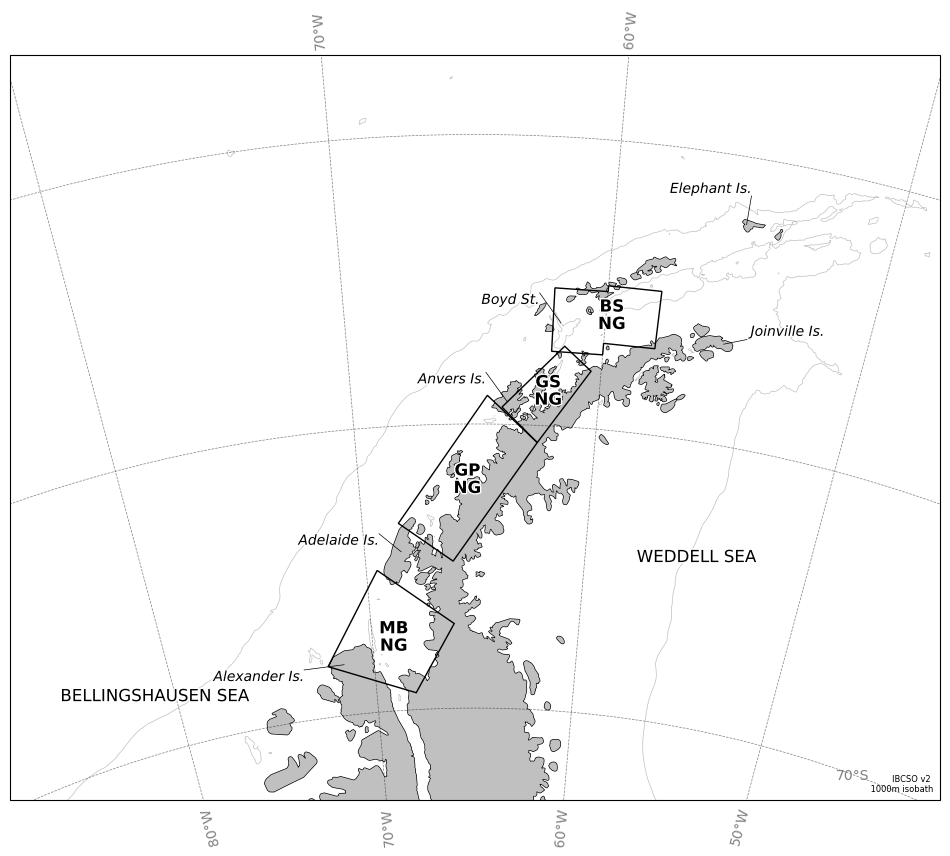

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10), subplot_kw={'projection': ccrs.SouthPolarStereo(central_longitude=-65)})
# extent = [275, 310, -68, -62]
extent = [-80, -50, -71, -58]

# Set up the map
plot_region(ax, extent)  # Adds coastline, land, and gridlines
plot_contour(ax, extent)  # Adds bathymetry contours

# Plot the reference map
plot_reference_map_with_labels(ax, extent, locations, location_labels, location_order, sea_names, place_names)
plt.show()

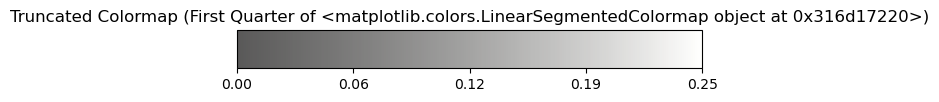

In [17]:
# File Paths to data
repo_path = '/Users/zephyrsylvester/repos/circumpolar-connectivity-analysis/'
data_path = repo_path + 'data/'
fig_path = repo_path + 'figures/'

ibsco_path = data_path + 'IBSCO/'

tab_path = fig_path + 'tables/'
map_path = fig_path + 'maps/'

# Path to the downloaded NetCDF file
nc_path = ibsco_path + 'IBCSO_v2_bed_WGS84_500m_APregion.nc'
# nc_path = ibsco_path + 'IBCSO_v2_bed_WGS84_500m_SWSect.nc'

# Open the NetCDF file using xarray
ds_bathy = xr.open_dataset(nc_path)
# Extract the bathymetry data
bathymetry = ds_bathy['z']

# Tell it what to plot
masked_bathymetry = np.ma.masked_invalid(bathymetry)

# Define depth intervals (e.g., every 500 meters)
depth_intervals = np.arange(-9000, 1000, 500)  # Adjust the range as needed

cmap=cmo.gray


# Create a truncated colormap

# Tighten colormap
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    new_cmap = mcolors.LinearSegmentedColormap.from_list(
        f'trunc({cmap.name},{minval:.2f},{maxval:.2f})',
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

truncated_cmap = truncate_colormap(cmap, 0.4, 1)

# Plot the truncated colormap
fig, ax = plt.subplots(figsize=(6, 1))
fig.subplots_adjust(bottom=0.5)

# Create a color bar with the truncated colormap
cbar = fig.colorbar(
    plt.cm.ScalarMappable(cmap=truncated_cmap),
    cax=ax, orientation='horizontal', ticks=np.linspace(0, 1, 5)
)
cbar.ax.set_xticklabels([f'{x:.2f}' for x in np.linspace(0, 0.25, 5)])

# Add title and labels
cbar.ax.set_title(f'Truncated Colormap (First Quarter of {cmap.title})')

# Show the plot
plt.show()

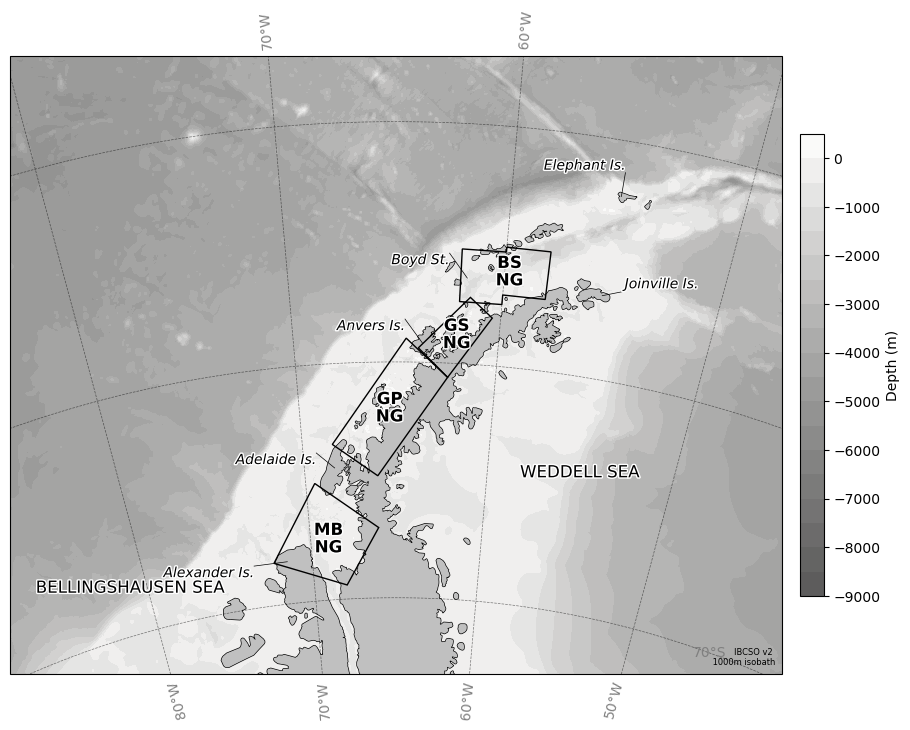

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10), subplot_kw={'projection': ccrs.SouthPolarStereo(central_longitude=-65)})
# extent = [275, 310, -68, -62]
extent = [-80, -50, -71, -58]

# Set up the map
plot_region(ax, extent)  # Adds coastline, land, and gridlines
plot_contour(ax, extent)  # Adds bathymetry contours
bathy = ax.contourf(bathymetry['lon'], bathymetry['lat'], masked_bathymetry,
            levels=depth_intervals, cmap=truncated_cmap,
            transform=ccrs.PlateCarree(), zorder=0)
# Plot the reference map
plot_reference_map_with_labels(ax, extent, locations, location_labels, location_order, sea_names, place_names)

#  Colorbar for Bathymetry ---
cbar = fig.colorbar(bathy, ax=ax, orientation='vertical', shrink=0.6, pad=0.02)
cbar.set_label('Depth (m)', fontsize=10)

plt.show()

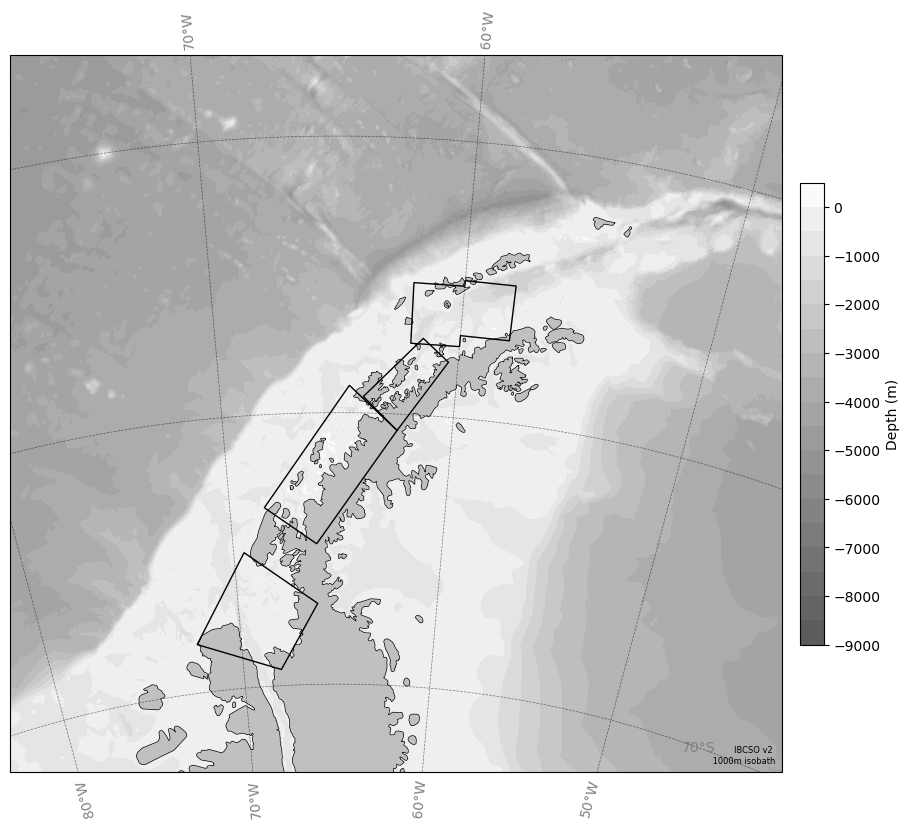

In [22]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10), subplot_kw={'projection': ccrs.SouthPolarStereo(central_longitude=-65)})
# extent = [275, 310, -68, -62]
extent = [-76, -50, -71, -58]

# Set up the map
plot_region(ax, extent)  # Adds coastline, land, and gridlines
plot_contour(ax, extent)  # Adds bathymetry contours
bathy = ax.contourf(bathymetry['lon'], bathymetry['lat'], masked_bathymetry,
            levels=depth_intervals, cmap=truncated_cmap,
            transform=ccrs.PlateCarree(), zorder=0)
# Plot the nurserys
plot_nurseries_bw(ax, extent, locations)

#  Colorbar for Bathymetry ---
cbar = fig.colorbar(bathy, ax=ax, orientation='vertical', shrink=0.6, pad=0.02)
cbar.set_label('Depth (m)', fontsize=10)
plt.savefig('figures/maps/blank-nurserymap', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10), subplot_kw={'projection': ccrs.SouthPolarStereo(central_longitude=-65)})
# extent = [275, 310, -68, -62]
extent = [-76, -50, -71, -58]

# Set up the map
plot_region(ax, extent)  # Adds coastline, land, and gridlines
plot_contour(ax, extent)  # Adds bathymetry contours
bathy = ax.contourf(bathymetry['lon'], bathymetry['lat'], masked_bathymetry,
            levels=depth_intervals, cmap=truncated_cmap,
            transform=ccrs.PlateCarree(), zorder=0)
# Plot the nurserys
plot_nurseries_bw(ax, extent, locations)

#  Colorbar for Bathymetry ---
cbar = fig.colorbar(bathy, ax=ax, orientation='vertical', shrink=0.6, pad=0.02)
cbar.set_label('Depth (m)', fontsize=10)
plt.savefig('figures/maps/blank-nurserymap', dpi=300, bbox_inches='tight')
plt.show()

In [23]:
def plot_2x2_nursery_basemap(nurseries, extent, bathymetry, masked_bathymetry, depth_intervals, truncated_cmap, save_path=None):
    """
    Plot a 2x2 grid of nursery base maps with bathymetry, one NG per panel.
    """
    fig, axs = plt.subplots(2, 2, figsize=(14, 12),
                            subplot_kw={'projection': ccrs.SouthPolarStereo(central_longitude=-65)},
                            constrained_layout=True)

    for ax, nursery in zip(axs.flat, nurseries):
        # Base map layers
        ax.set_extent(extent, crs=ccrs.PlateCarree())
        plot_region(ax, extent)
        plot_contour(ax, extent)

        # Bathymetry
        bathy = ax.contourf(
            bathymetry['lon'], bathymetry['lat'], masked_bathymetry,
            levels=depth_intervals, cmap=truncated_cmap,
            transform=ccrs.PlateCarree(), zorder=0
        )

        # Plot single nursery
        plot_nurseries_bw(ax, extent, {nursery: locations[nursery]})

        ax.set_title(location_labels.get(nursery, nursery), fontsize=12)

    # Shared colorbar
    cbar = fig.colorbar(bathy, ax=axs, orientation='vertical', shrink=0.6, pad=0.02)
    cbar.set_label('Depth (m)', fontsize=10)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Saved map to {save_path}")
    plt.show()

✅ Saved map to figures/maps/2x2_nursery_basemap.png


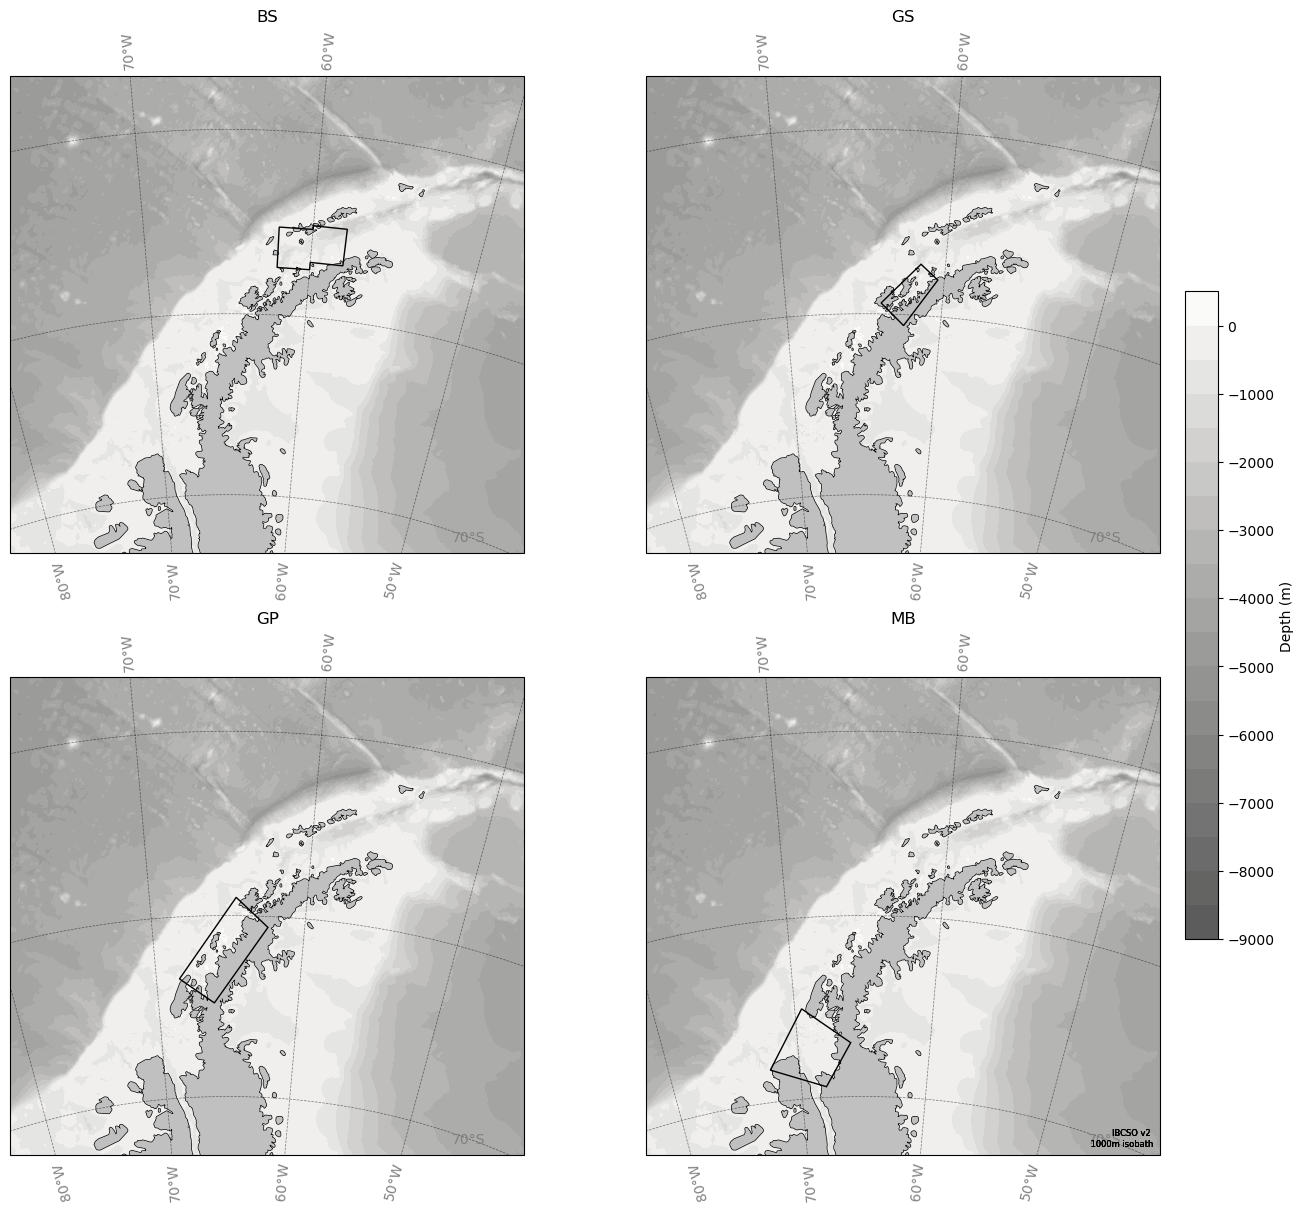

In [24]:
nurseries = ['BS', 'GERL', 'GP', 'MB2']
extent = [-76, -50, -71, -58]

plot_2x2_nursery_basemap(
    nurseries=nurseries,
    extent=extent,
    bathymetry=bathymetry,
    masked_bathymetry=masked_bathymetry,
    depth_intervals=depth_intervals,
    truncated_cmap=truncated_cmap,
    save_path='figures/maps/2x2_nursery_basemap.png'
)

In [ ]:
# place_names = [
#     {"name": "Elephant Is.", "lon": 304.7, "lat": -61.15,  "ha": "center", "va": "bottom", "angle": 90},
#     {"name": "Joinville Is.", "lon": 304.6, "lat": -63.25, "ha": "center", "va": "bottom", "angle": 90},
#     {"name": "Boyd St.", "lon": 298.3, "lat": -63.2, "ha": "center", "va": "top", "angle": 135},
#     {"name": "Anvers Is.", "lon": 296.3, "lat": -64.6,  "ha": "center", "va": "top", "angle": 150},
#     {"name": "Adelaide Is.", "lon": 291.65, "lat": -67.2,  "ha": "center", "va": "top", "angle": 160},
#     {"name": "Alexander Is.", "lon": 288.5, "lat": -69.1, "ha": "center", "va": "top", "angle": 180}
# ]

# sea_names = [
#     {"name": "WEDDELL SEA", "lon": 308, "lat": -66, "ha": "center", "va": "center"},
#     {"name": "BELLINGSHAUSEN SEA", "lon": 280, "lat": -70, "ha": "center", "va": "center"}
# ]

In [ ]:
# fig, ax = plt.subplots(1, 1, figsize=(12, 10), subplot_kw={'projection': ccrs.SouthPolarStereo()})
# extent = [275, 310, -68, -62]

# # Set up the map
# plot_region(ax, extent)  # Adds coastline, land, and gridlines
# plot_contour(ax, extent)  # Adds bathymetry contours

# # Plot
# plot_reference_map_with_labels(ax, extent, locations, location_labels, location_order, sea_names, place_names)
# plt.show()

In [20]:
def plot_reference_map_with_labels(ax, extent, locations, location_labels, location_order, sea_names, place_names, box_zorder=6, label_fontsize=12, place_fontsize=10):
    """
    Plot nurseries with bounding boxes, labels, and additional sea and place names.

    Parameters:
        ax (matplotlib.axes): The matplotlib axis to plot on.
        extent (list): The extent of the map in [lon_min, lon_max, lat_min, lat_max].
        locations (dict): Dictionary of locations with bounding boxes.
        location_labels (dict): Human-readable labels for locations.
        location_order (dict): Order for locations.
        sea_names (list): List of sea names with coordinates and labels.
        place_names (list): List of place names with coordinates and labels.
        box_zorder (int): Z-order for the boxes.
        label_fontsize (int): Font size for nursery and sea labels.
        place_fontsize (int): Font size for place names.
    """
    ax.set_extent(extent, crs=ccrs.PlateCarree())

    # Plot nurseries with labels
    for region in sorted(locations.keys(), key=lambda x: location_order[x]):
        for box in locations[region]['boxes']:
            lonpoly = box['lonpoly']
            latpoly = box['latpoly']
            
            # Plot bounding box
            poly = Polygon(list(zip(lonpoly, latpoly)), closed=True, fill=False, edgecolor='k', zorder=box_zorder, transform=ccrs.PlateCarree())
            ax.add_patch(poly)
            
            # Calculate centroid for label
            lon_center = np.mean(lonpoly)
            lat_center = np.mean(latpoly)
            
            # Add the label at the centroid with white outline
            text = ax.text(
                lon_center, lat_center, f"{location_labels.get(region, region)}\nNG", 
                fontsize=label_fontsize, color='black', ha='center', va='center',
                transform=ccrs.PlateCarree(), zorder=box_zorder + 1
            )
            # Add white outline to text
            text.set_path_effects([
                path_effects.Stroke(linewidth=2, foreground='white'),
                path_effects.Normal()
            ])

    # Plot sea names
    for sea in sea_names:
        ax.text(
            sea['lon'], sea['lat'], sea['name'], 
            fontsize=label_fontsize, color='black', ha=sea.get('ha', 'center'), va=sea.get('va', 'center'),
            transform=ccrs.PlateCarree(), zorder=box_zorder + 1,
            path_effects=[
                path_effects.Stroke(linewidth=2, foreground='white'),
                path_effects.Normal()
            ]
        )

    # Plot place names with lines
    for place in place_names:
        label_lon = place['lon'] - 1  # Adjust label position slightly to the left
        label_lat = place['lat']

        # Draw a line connecting the place point to the label
        ax.plot([place['lon'], label_lon], [place['lat'], label_lat], 
                color='black', linewidth=0.5, transform=ccrs.PlateCarree(), zorder=box_zorder)

        # Add the place name label
        ax.text(
            label_lon, label_lat, place['name'], 
            fontsize=place_fontsize, color='black', ha=place.get('ha', 'right'), va=place.get('va', 'center'),
            transform=ccrs.PlateCarree(), zorder=box_zorder + 1,
            path_effects=[
                path_effects.Stroke(linewidth=2, foreground='white'),
                path_effects.Normal()
            ]
        )

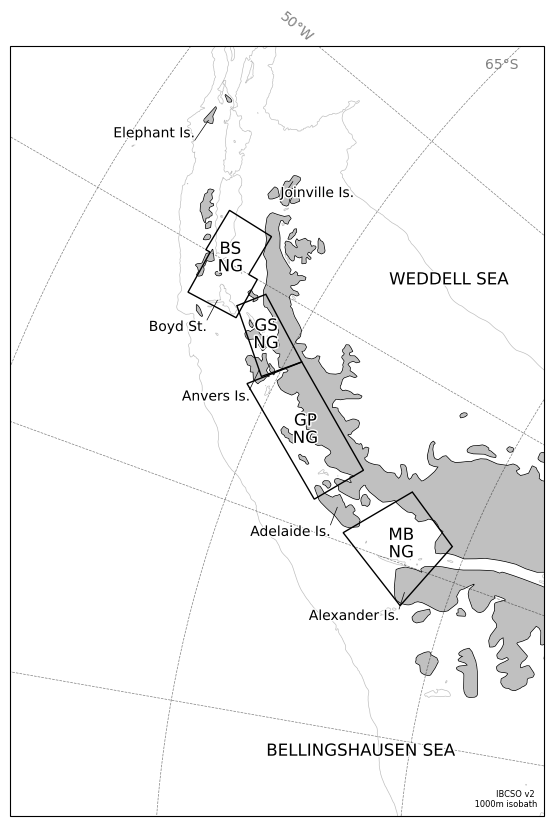

In [21]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10), subplot_kw={'projection': ccrs.SouthPolarStereo()})
extent = [275, 310, -68, -62]

plot_region(ax, extent)  # Adds coastline, land, and gridlines
plot_contour(ax, extent)  # Adds bathymetry contours

plot_reference_map_with_labels(ax, extent, locations, location_labels, location_order, sea_names, place_names)

plt.show()

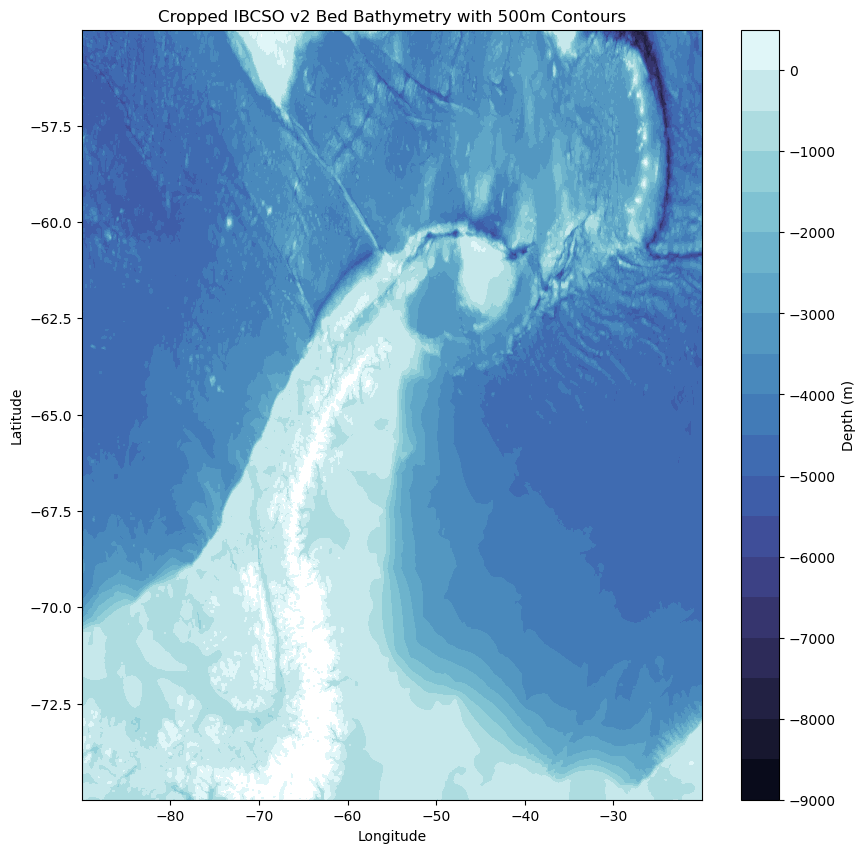

In [22]:
# Quick Check
# Extract the bathymetry data
bathymetry = ds['z']

# Tell it what to plot
to_plot = bathymetry

# Define depth intervals (e.g., every 500 meters)
depth_intervals = np.arange(-9000, 1000, 500)  # Adjust the range as needed

# Plot the contours
plt.figure(figsize=(10, 10))
contour = plt.contourf(to_plot['lon'], to_plot['lat'], to_plot,
                       levels=depth_intervals, cmap=cmo.ice)
plot_region(ax, extent)  # Sets up the map with coastline, land, gridlines, etc.

plt.colorbar(contour, label='Depth (m)')
plt.title('Cropped IBCSO v2 Bed Bathymetry with 500m Contours')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [23]:
# Tighten colormap
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    new_cmap = mcolors.LinearSegmentedColormap.from_list(
        f'trunc({cmap.name},{minval:.2f},{maxval:.2f})',
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

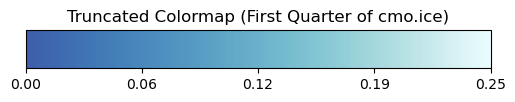

In [24]:
cmap=cmo.ice

# Create a truncated colormap
truncated_cmap = truncate_colormap(cmo.ice, 0.4, 1)

# Plot the truncated colormap
fig, ax = plt.subplots(figsize=(6, 1))
fig.subplots_adjust(bottom=0.5)

# Create a color bar with the truncated colormap
cbar = fig.colorbar(
    plt.cm.ScalarMappable(cmap=truncated_cmap),
    cax=ax, orientation='horizontal', ticks=np.linspace(0, 1, 5)
)
cbar.ax.set_xticklabels([f'{x:.2f}' for x in np.linspace(0, 0.25, 5)])

# Add title and labels
cbar.ax.set_title('Truncated Colormap (First Quarter of cmo.ice)')

# Show the plot
plt.show()

In [36]:
# # Define depth intervals (e.g., every 500 meters)
# depth_int_500 = np.arange(-10000, 0, 500)  # Adjust the range as needed
# depth_int_1000 = np.arange(-10000, -500, 1000)  # Adjust the range as needed


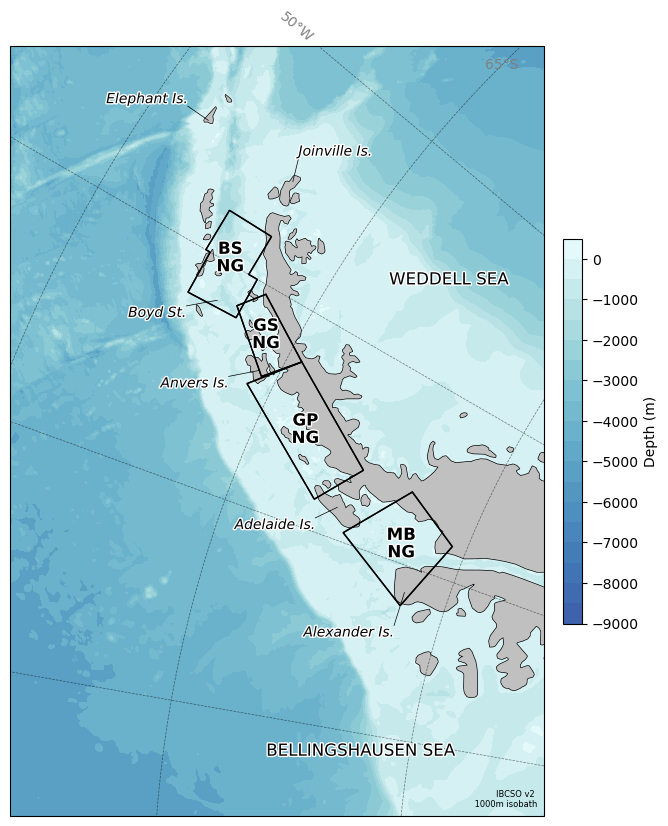

In [38]:
# Define depth intervals and colormap
depth_intervals = np.arange(-9000, 1000, 500)  # Adjust to cover full depth range
cmap = truncated_cmap  # Using cmocean deep colormap for bathymetry
# extent = extents['base']  # Your defined extent for the region
# extent = [278, 316, -68, -62]
extent = [275, 310, -68, -62]

# Mask missing data (NaNs)
masked_bathymetry = np.ma.masked_invalid(bathymetry)

# Initialize the figure with South Polar Stereographic projection
fig, ax = plt.subplots(1, 1, figsize=(12, 10),
                       subplot_kw={'projection': ccrs.SouthPolarStereo(), 'facecolor': '#ecf4f8'})

# Plot the region map (coastlines, gridlines, etc.)
plot_region(ax, extent)  # Your helper function for base map setup
plot_contour(ax, extent)

# Plot the bathymetry contours
contour = ax.contourf(
    bathymetry['lon'], bathymetry['lat'], masked_bathymetry,
    levels=depth_intervals, cmap=cmap,
    transform=ccrs.PlateCarree(), zorder=0
)

# Overlay any additional features
plot_nurseries_bw(ax, extent, locations)
plot_reference_map_with_labels(ax, extent, locations, location_labels, location_order, sea_names, place_names)

# Add colorbar
cbar = plt.colorbar(contour, ax=ax, orientation='vertical', shrink=0.5, pad=0.02)
cbar.set_label('Depth (m)')

# Save and show the map
final_path = 'figures/manuscript-versions/'
map_path = 'figures/maps/'
plt.savefig(final_path + 'Reference-Map-150.png', dpi=150, bbox_inches='tight')
plt.show()

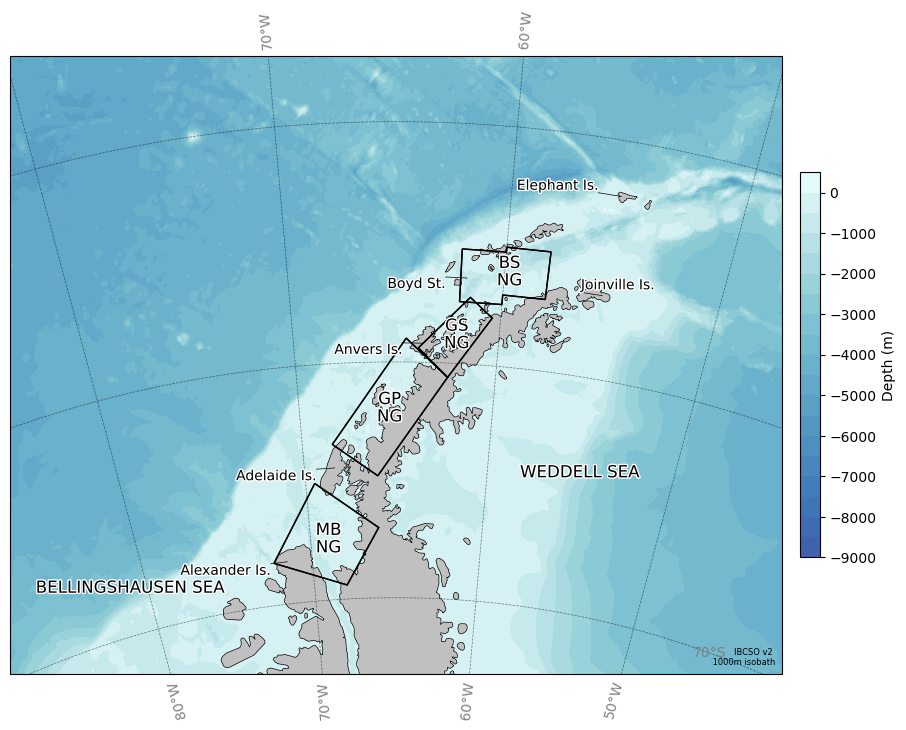

In [25]:
# Define depth intervals and colormap
depth_intervals = np.arange(-9000, 1000, 500)  # Adjust to cover full depth range
cmap = truncated_cmap  # Using cmocean deep colormap for bathymetry
# extent = extents['base']  # Your defined extent for the region
# extent = [278, 316, -68, -62]
extent = [-80, -50, -71, -58]

# Mask missing data (NaNs)
masked_bathymetry = np.ma.masked_invalid(bathymetry)

# Initialize the figure with South Polar Stereographic projection
fig, ax = plt.subplots(1, 1, figsize=(12, 10),
                       subplot_kw={'projection': ccrs.SouthPolarStereo(central_longitude=-65), 'facecolor': '#ecf4f8'})

# Plot the region map (coastlines, gridlines, etc.)
plot_region(ax, extent)  # Your helper function for base map setup
plot_contour(ax, extent)

# Plot the bathymetry contours
contour = ax.contourf(
    bathymetry['lon'], bathymetry['lat'], masked_bathymetry,
    levels=depth_intervals, cmap=cmap,
    transform=ccrs.PlateCarree(), zorder=0
)

# Overlay any additional features
plot_nurseries_bw(ax, extent, locations)
plot_reference_map_with_labels(ax, extent, locations, location_labels, location_order, sea_names, place_names)

# Add colorbar
cbar = plt.colorbar(contour, ax=ax, orientation='vertical', shrink=0.5, pad=0.02)
cbar.set_label('Depth (m)')

# Save and show the map
map_path = 'figures/maps/'
plt.savefig(map_path + 'Reference-Map-recentered.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# # Define depth intervals (e.g., every 500 meters)
# depth_int = depth_intervals
# cmap = truncated_cmap
# extent=extents['hires']


# fig, ax = plt.subplots(1, 1, figsize=(10, 10), subplot_kw={'projection': ccrs.SouthPolarStereo(), 'facecolor': '#ecf4f8'})
# plot_region(ax, extent)  # Sets up the map with coastline, land, gridlines, etc.
# plot_contour(ax, extent)
# plot_nurseries_bw(ax, extent, locations)
# contour = ax.contourf(bathymetry['lon'], bathymetry['lat'], bathymetry,
#                       cmap=cmap,
#                       transform=ccrs.PlateCarree(), zorder=0)

# plt.savefig(map_path+'Reference-Map-region.png', dpi=300, bbox_inches='tight')
# plt.show()

In [ ]:
# Initialize the figure and axis with a projection
fig, ax = plt.subplots(figsize=(10, 10),
                       subplot_kw={'projection': ccrs.PlateCarree()})
plot_region(ax, extent)

# Plot the bathymetry data as contours
contour = ax.contourf(to_plot['lon'], to_plot['lat'], to_plot,
                      levels=depth_intervals, cmap=cmo.ice, transform=ccrs.PlateCarree())

# Add a colorbar
cbar = plt.colorbar(contour, ax=ax, orientation='vertical', shrink=0.5, pad=0.02)
cbar.set_label('Depth (m)')

# Add title and labels
ax.set_title('Antarctic Peninsula Bathymetry with 500m Contours')

plt.show()

In [ ]:
# # Read in your data!
# summary_file = 'nursery_use_summary_inbound.csv'
# traj_file = 'processed_trajectories_21dfilter_inbound.csv'
# # output_nc_path = ibsco_path + 'IBCSO_v2_bed_WGS84_500m_APregion.nc'
# # ap_bathymetry.to_netcdf(output_nc_path)
# summary=pd.read_csv(output_path + summary_file) 
# df_traj=pd.read_csv(output_path + traj_file) 

In [ ]:
# # Names, Orders, Etc
# locations = ['BS', 'GERL', 'GP', 'MB']
# location_labels = {'BS': 'Bransf.', 'GERL': 'Gerl.', 'GP': 'Grand.', 'MB':'M. Bay'}
# location_order = ['BS', 'GERL', 'GP', 'MB']

# # Define location colors (replace with actual values)
# location_colors = {
#     'BS': '#d55e00',
#     'GERL': '#029e73',
#     'GP': '#cc78bc',
#     'MB': '#0173b2',
#     'outside': 'gray'
# }

# # Define region coordinates
# boxes = {
#     'BS': [
#         {'lonpoly': [-62.0, -60.0, -60.0, -62.0], 'latpoly': [-63.7, -63.7, -62.6, -62.6]},
#         {'lonpoly': [-60.0, -58.0, -58.0, -60.0], 'latpoly': [-63.5, -63.5, -62.5, -62.5]}
#     ],
#     'GERL': {'lonpoly': [-63.9, -61.5, -60.4, -62.4], 'latpoly': [-64.7, -63.6, -64.0, -65.3]},
#     'GP': {'lonpoly': [-68.4, -64.5, -62.4, -66.0], 'latpoly': [-66.7, -64.5, -65.3, -67.4]},
#     'MB': {'lonpoly': [-72.3, -69.5, -66.0, -68.0], 'latpoly': [-69.1, -67.5, -68.5, -69.7]}
# }

# # Names, Orders, Etc
# hypotheses = {'hi_res'}
# hypothesis_labels = {'hi_res': 'HR Ice'}
# hypothesis_order = ['hi_res']

# # Define the extent of the plot
# extent = [275, 311, -72, -59]

# # C3 Manuscript Standard Plot Window
# extent_AP_base = [275, 311, -72, -59]

# extent_AP_expand = [274, 316 -71, -60]

# extent_AP_toSG = [281.6, 322, -65, -60]
# extent_AP_toAM = [271, 308, -71, -62]

# Quick Plot

In [ ]:
# Helper function to plot the base map and all boxes
def plot_all_boxes(ax, extent, boxes, box_zorder=6):
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, zorder=2)
    ax.add_feature(cfeature.LAND, facecolor='lightgrey', zorder=2)
    gl = ax.gridlines(linewidth=.5, color='black', alpha=0.5, linestyle='--', zorder=1)
    gl.xlocator = ticker.FixedLocator(range(-180, 181, 10))
    gl.ylocator = ticker.FixedLocator(range(-90, 91, 5))

    # Plot all bounding boxes
    for region, coords in boxes.items():
        if isinstance(coords, list):
            # Multiple subregions
            for subregion in coords:
                lonpoly = subregion['lonpoly']
                latpoly = subregion['latpoly']
                poly = Polygon(list(zip(lonpoly, latpoly)), closed=True, fill=False, edgecolor='black', zorder=box_zorder, transform=ccrs.PlateCarree())
                ax.add_patch(poly)
        else:
            # Single region
            lonpoly = coords['lonpoly']
            latpoly = coords['latpoly']
            poly = Polygon(list(zip(lonpoly, latpoly)), closed=True, fill=False, edgecolor='black', zorder=box_zorder, transform=ccrs.PlateCarree())
            ax.add_patch(poly)


In [ ]:
# Create the figure and subplots for the facet plot (one for each year)
fig, ax = plt.subplots(1, 1, figsize=(5, 5), subplot_kw={'projection': ccrs.SouthPolarStereo()})
plot_all_boxes(ax, extent, boxes)  # Plot all regions' bounding boxes


In [ ]:
# Helper function to plot the base map and all boxes
def plot_all_boxes(ax, extent, boxes, box_zorder=6):
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, zorder=2)
    ax.add_feature(cfeature.LAND, facecolor='lightgrey', zorder=2)

    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='black', alpha=0.5, linestyle='--', zorder=1)
    gl.xlocator = ticker.FixedLocator(range(-180, 181, 10))
    gl.ylocator = ticker.FixedLocator(range(-90, 91, 5))
    gl.xlabel_style = {'size': 10, 'color': 'gray'}
    gl.ylabel_style = {'size': 10, 'color': 'gray'}

    # Plot all bounding boxes
    for region, coords in boxes.items():
        if isinstance(coords, list):
            # Multiple subregions
            for subregion in coords:
                lonpoly = subregion['lonpoly']
                latpoly = subregion['latpoly']
                poly = Polygon(list(zip(lonpoly, latpoly)), closed=True, fill=False, edgecolor=location_colors[region], zorder=box_zorder, transform=ccrs.PlateCarree())
                ax.add_patch(poly)
        else:
            # Single region
            lonpoly = coords['lonpoly']
            latpoly = coords['latpoly']
            poly = Polygon(list(zip(lonpoly, latpoly)), closed=True, fill=False, edgecolor=location_colors[region], zorder=box_zorder, transform=ccrs.PlateCarree())
            ax.add_patch(poly)

    # Add legend
    legend_handles = [Line2D([0], [0], color=location_colors[loc], lw=2, label=location_labels[loc]) for loc in location_order]
    ax.legend(handles=legend_handles, loc='upper left', title='Nurseries')


In [ ]:

# Create the figure and subplots for the facet plot (one for each year)
fig, ax = plt.subplots(1, 1, figsize=(7, 7), subplot_kw={'projection': ccrs.SouthPolarStereo()})
plot_all_boxes(ax, extent, boxes)  # Plot all regions' bounding boxes

# Add title and labels
# plt.title('Regional Boundaries in the Antarctic', fontsize=15)
plt.show()


# Add IBSCO Bathy

In [ ]:
# Tighten colormap
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    new_cmap = mcolors.LinearSegmentedColormap.from_list(
        f'trunc({cmap.name},{minval:.2f},{maxval:.2f})',
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

In [ ]:
cmap=cmo.ice

# Create a truncated colormap
truncated_cmap = truncate_colormap(cmo.ice, 0.4, 1)

# Plot the truncated colormap
fig, ax = plt.subplots(figsize=(6, 1))
fig.subplots_adjust(bottom=0.5)

# Create a color bar with the truncated colormap
cbar = fig.colorbar(
    plt.cm.ScalarMappable(cmap=truncated_cmap),
    cax=ax, orientation='horizontal', ticks=np.linspace(0, 1, 5)
)
cbar.ax.set_xticklabels([f'{x:.2f}' for x in np.linspace(0, 0.25, 5)])

# Add title and labels
cbar.ax.set_title('Truncated Colormap (First Quarter of cmo.ice)')

# Show the plot
plt.show()

In [ ]:

# Helper function to plot the base map and all boxes
def plot_all_boxes(ax, extent, boxes, box_zorder=6):
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, zorder=2)
    ax.add_feature(cfeature.LAND, facecolor='lightgrey', zorder=2)


    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='black', alpha=0.5, linestyle='--', zorder=1)
    gl.xlocator = ticker.FixedLocator(range(-180, 181, 10))
    gl.ylocator = ticker.FixedLocator(range(-90, 91, 5))
    gl.xlabel_style = {'size': 8, 'color': 'gray'}
    gl.ylabel_style = {'size': 8, 'color': 'gray'}
    
    # Plot all bounding boxes
    for region, coords in boxes.items():
        if isinstance(coords, list):
            # Multiple subregions
            for subregion in coords:
                lonpoly = subregion['lonpoly']
                latpoly = subregion['latpoly']
                poly = Polygon(list(zip(lonpoly, latpoly)), closed=True, fill=False, edgecolor=location_colors[region], zorder=box_zorder, transform=ccrs.PlateCarree())
                ax.add_patch(poly)
        else:
            # Single region
            lonpoly = coords['lonpoly']
            latpoly = coords['latpoly']
            poly = Polygon(list(zip(lonpoly, latpoly)), closed=True, fill=False, edgecolor=location_colors[region], zorder=box_zorder, transform=ccrs.PlateCarree())
            ax.add_patch(poly)

    # Add legend
    legend_handles = [Line2D([0], [0], color=location_colors[loc], lw=2, label=location_labels[loc]) for loc in location_order]
    ax.legend(handles=legend_handles, loc='upper left', title='Nurseries')

In [ ]:
# Define depth intervals (e.g., every 500 meters)
depth_int_500 = np.arange(-10000, 0, 500)  # Adjust the range as needed
depth_int_1000 = np.arange(-6000, 1000, 1000)  # Adjust the range as needed


In [ ]:

# Helper function to plot the base map and all boxes
def plot_refmap(ax, extent):
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, zorder=2)
    ax.add_feature(cfeature.LAND, facecolor='lightgrey', zorder=2)

    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='black', alpha=0.5, linestyle='--', zorder=1)
    gl.xlocator = ticker.FixedLocator(range(-180, 181, 10))
    gl.ylocator = ticker.FixedLocator(range(-90, 91, 5))
    gl.xlabel_style = {'size': 8, 'color': 'gray'}
    gl.ylabel_style = {'size': 8, 'color': 'gray'}
    

In [ ]:
# Define depth intervals (e.g., every 500 meters)
depth_int = depth_int_500
cmap = truncated_cmap
extent=extents['hires']

# Create the figure and subplots for the facet plot (one for each year)
fig, ax = plt.subplots(1, 1, figsize=(10, 10), subplot_kw={'projection': ccrs.SouthPolarStereo()})
plot_refmap(ax, extent)  # Plot all regions' bounding boxes

# Plot the bathymetry contours on the same axis
contour = ax.contourf(bathymetry['lon'], bathymetry['lat'], bathymetry, levels=depth_int, cmap=cmap, transform=ccrs.PlateCarree(), zorder=0)
plt.colorbar(contour, ax=ax, label='Depth (m)', orientation='horizontal', shrink = 0.6)

# Add small text in the bottom right corner
plt.annotate('IBCSO v2 Bed Bathymetry', 
             xy=(1, 0), xycoords='axes fraction', fontsize=6,
             xytext=(-5, 5), textcoords='offset points',
             ha='right', va='bottom')

# Add title and labels
# plt.title('500m Contours', fontsize=12)
# plt.savefig(map_path+'500m-Reference-Map.png', dpi=300, bbox_inches='tight')
# Show the plot
plt.show()

## Nursery Plots

In [1]:
# Define depth intervals (e.g., every 500 meters)
depth_int = depth_int_500
cmap = truncated_cmap

# Create the figure and subplots for the facet plot (one for each year)
fig, ax = plt.subplots(1, 1, figsize=(10, 10), subplot_kw={'projection': ccrs.SouthPolarStereo()})
plot_all_boxes(ax, extent, boxes)  # Plot all regions' bounding boxes

# Plot the bathymetry contours on the same axis
contour = ax.contourf(bathymetry['lon'], bathymetry['lat'], bathymetry, levels=depth_int, cmap=cmap, transform=ccrs.PlateCarree(), zorder=0)
plt.colorbar(contour, ax=ax, label='Depth (m)', orientation='horizontal', shrink = 0.6)

# Add small text in the bottom right corner
plt.annotate('IBCSO v2 Bed Bathymetry', 
             xy=(1, 0), xycoords='axes fraction', fontsize=6,
             xytext=(-5, 5), textcoords='offset points',
             ha='right', va='bottom')

# Add title and labels
# plt.title('500m Contours', fontsize=12)
plt.savefig(map_path+'500m-Nursery-Map.png', dpi=300, bbox_inches='tight')
# Show the plot
plt.show()

NameError: name 'depth_int_500' is not defined

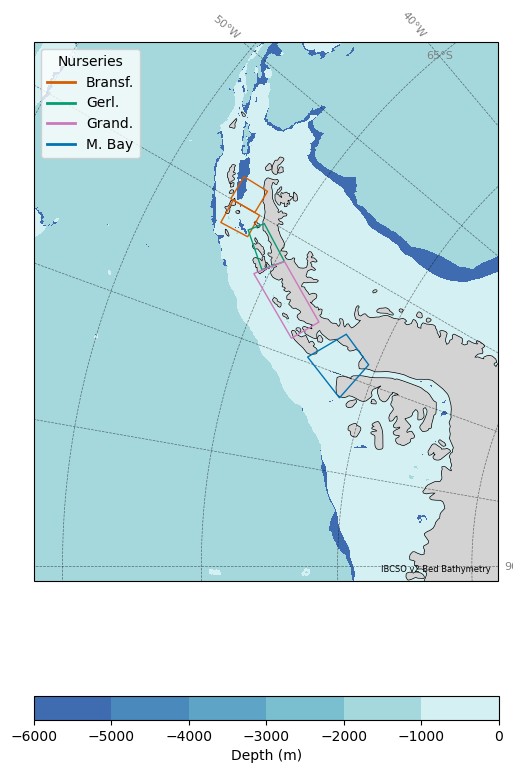

In [21]:
# Define depth intervals (e.g., every 500 meters)
depth_int = depth_int_1000

# Create the figure and subplots for the facet plot (one for each year)
fig, ax = plt.subplots(1, 1, figsize=(10, 10), subplot_kw={'projection': ccrs.SouthPolarStereo(), 'facecolor': '#4989bc'})
plot_all_boxes(ax, extent, boxes)  # Plot all regions' bounding boxes

# Plot the bathymetry contours on the same axis
contour = ax.contourf(bathymetry['lon'], bathymetry['lat'], bathymetry, levels=depth_int, cmap=cmap, transform=ccrs.PlateCarree(), zorder=0)
plt.colorbar(contour, ax=ax, extend='both', label='Depth (m)', orientation='horizontal', shrink = 0.6)

# Add small text in the bottom right corner
plt.annotate('IBCSO v2 Bed Bathymetry', 
             xy=(1, 0), xycoords='axes fraction', fontsize=6,
             xytext=(-5, 5), textcoords='offset points',
             ha='right', va='bottom')

# Add title and labels
# plt.title('1000m Contours', fontsize=12)
plt.savefig(map_path+'Nursery-Map-1000m.png', dpi=300, bbox_inches='tight')
# Show the plot
plt.show()

array([-1000])

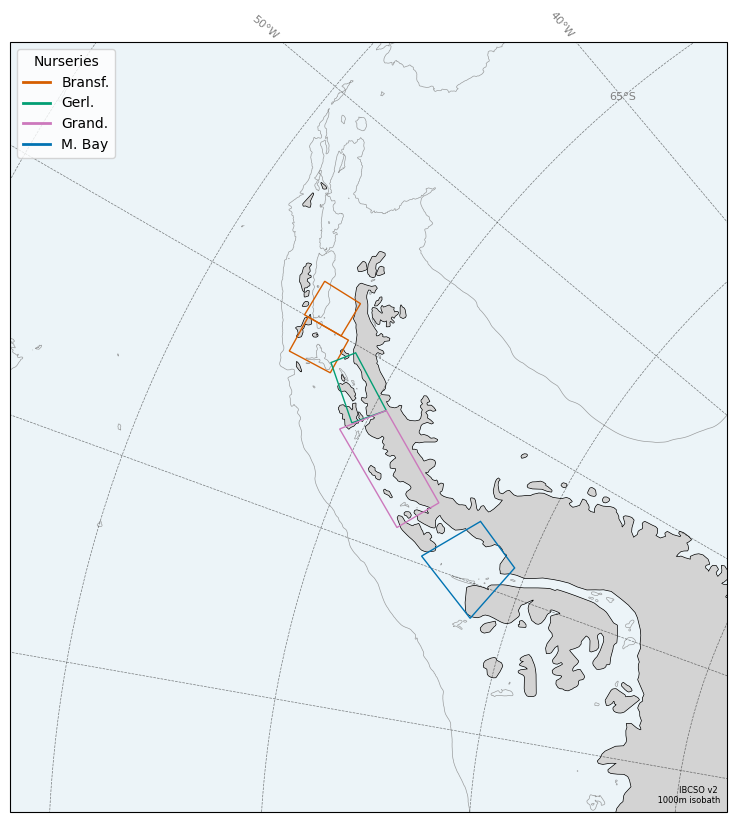

In [95]:
# Define depth intervals 
depth_int_1k_m = np.arange(-1000, 0, 1000)  # Adjust the range as needed
depth_int = depth_int_1k_m


# Create the figure and subplots for the facet plot (one for each year)
fig, ax = plt.subplots(1, 1, figsize=(10, 10), subplot_kw={'projection': ccrs.SouthPolarStereo(), 'facecolor': '#ecf4f8'})
plot_all_boxes(ax, extent, boxes)  # Plot all regions' bounding boxes

# Plot the bathymetry contours on the same axis using contour for lines
contour = ax.contour(bathymetry['lon'], bathymetry['lat'], bathymetry,
                     levels=depth_int, linestyles = 'solid', linewidths=0.5, colors='grey', alpha=0.75,
                     transform=ccrs.PlateCarree(), zorder=0)

# Add small text in the bottom right corner
plt.annotate('IBCSO v2 \n 1000m isobath', 
             xy=(1, 0), xycoords='axes fraction', fontsize=6,
             xytext=(-5, 5), textcoords='offset points',
             ha='right', va='bottom')

# Add title and labels
# plt.title('1000m Contours', fontsize=12)
plt.savefig(map_path+'Nursery-Map-contours_1k_m.png', dpi=300, bbox_inches='tight')
# Show the plot
plt.show()